# Evaluate Models in Subgroups

## 1. Import Libraries

In [57]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from config_models import (
    OUTPUT_DIR,
    TEST_SUBGROUP_DATA_PATH,
    SUBGROUP_COLS,
)

from models_helpers import calculate_accuracy

## 2. Run Disclosure Control Helpers

In [58]:
%run ../sdc_helpers.py

## 3. Load Data

In [59]:
prediction_df = pd.read_csv(
    os.path.join(OUTPUT_DIR, "test_predictions.csv.gz")
)

test_subgroup_data = pd.read_csv(TEST_SUBGROUP_DATA_PATH)

eval_data = prediction_df.merge(
    test_subgroup_data,
    on=["patient_id", "hf_outcome"],
    how="left"
)

print("Predictions:", prediction_df.shape)
print("Subgroup data:", test_subgroup_data.shape)
print("Evaluation data:", eval_data.shape)

eval_data.head()

Predictions: (1000, 10)
Subgroup data: (1000, 18)
Evaluation data: (1000, 26)


,patient_id,hf_outcome,lr_prob,lr_pred,rf_prob,rf_pred,hgb_prob,hgb_pred,xgb_prob,xgb_pred,...,mltc_count,n_underserved,carehome_at_index,migrant,non_english_speaking,learndis,smi,substance_abuse,homeless,housebound
0,2243,1,0.490817,1,0.518709,1,0.786215,1,0.471220,1,...,0,0,0,0,0,0,0,0,0,0
1,8752,1,0.410824,0,0.475858,1,0.699460,0,0.452088,0,...,1,1,0,1,0,0,0,0,0,0
2,3332,1,0.630353,1,0.630268,1,0.836069,1,0.563755,1,...,0,2,1,1,0,0,0,0,0,0
3,3432,1,0.471217,1,0.466255,0,0.708428,0,0.478835,1,...,0,0,0,0,0,0,0,0,0,0
4,4858,0,0.554549,1,0.663855,1,0.871823,1,0.555099,1,...,0,1,0,1,0,0,0,0,0,0


## 4. Define Subgroups

In [60]:
subgroup_vars = [
    col for col in SUBGROUP_COLS
    if col not in ["patient_id", "hf_outcome"]
]

## 5. Evaluate Models in Subgroups

In [61]:
model_names = [
    col.replace("_prob", "")
    for col in eval_data.columns
    if col.endswith("_prob")
]

IS_DUMMY_DATA = os.getenv("OPENSAFELY_BACKEND") is None

if IS_DUMMY_DATA:
    min_n = 5
    min_events = 1
else:
    min_n = 2 * (DISCLOSURE_THRESHOLD + 1)
    min_events = DISCLOSURE_THRESHOLD + 1

print("Dummy data:", IS_DUMMY_DATA)
print("Minimum subgroup size:", min_n)
print("Minimum events/non-events:", min_events)

rows = []
confusion_rows = []

for model_name in model_names:
    prob_col = f"{model_name}_prob"
    pred_col = f"{model_name}_pred"

    for subgroup_var in subgroup_vars:
        for subgroup_level, df_sub in eval_data.groupby(subgroup_var, dropna=False):
            n = len(df_sub)
            n_events = int(df_sub["hf_outcome"].sum())
            n_nonevents = int(n - n_events)

            y_true = df_sub["hf_outcome"]
            y_pred = df_sub[pred_col].astype(int)

            tn, fp, fn, tp = confusion_matrix(
                y_true,
                y_pred,
                labels=[0, 1]
            ).ravel()

            confusion_rows.append(
                {
                    "model": model_name,
                    "subgroup_variable": subgroup_var,
                    "subgroup_level": subgroup_level,
                    "n": n,
                    "tn": tn,
                    "fp": fp,
                    "fn": fn,
                    "tp": tp,
                }
            )

            row = {
                "model": model_name,
                "subgroup_variable": subgroup_var,
                "subgroup_level": subgroup_level,
                "n": n,
                "n_events": n_events,
                "n_nonevents": n_nonevents,
                "event_rate": df_sub["hf_outcome"].mean(),
            }

            if n < min_n or n_events < min_events or n_nonevents < min_events:
                row.update({
                    "auc": np.nan,
                    "auc_pr": np.nan,
                    "brier": np.nan,
                    "accuracy": np.nan,
                    "precision": np.nan,
                    "recall": np.nan,
                    "f1": np.nan,
                    "sensitivity": np.nan,
                    "specificity": np.nan,
                })
            else:
                y_prob = df_sub[prob_col]

                performance = calculate_accuracy(
                    observed=y_true,
                    predicted=y_pred,
                )

                performance["auc"] = roc_auc_score(y_true, y_prob)
                performance["auc_pr"] = average_precision_score(y_true, y_prob)
                performance["brier"] = brier_score_loss(y_true, y_prob)
                performance["mean_predicted_risk"] = np.mean(y_prob)

                row.update(performance)

            rows.append(row)

subgroup_performance_df = pd.DataFrame(rows)
subgroup_confusion_df = pd.DataFrame(confusion_rows)

display(subgroup_performance_df.head())
display(subgroup_confusion_df.head())

Dummy data: True
Minimum subgroup size: 5
Minimum events/non-events: 1


,model,subgroup_variable,subgroup_level,n,n_events,n_nonevents,event_rate,observed_positive_rate,observed_negative_rate,predicted_positive_rate,...,positive_predictive_value,negative_predictive_value,true_positives,false_positives,true_negatives,false_negatives,auc,auc_pr,brier,mean_predicted_risk
0,lr,age_band,100+,164,128,36,0.780488,0.780488,0.219512,0.762195,...,0.784000,0.230769,98.0,27.0,9.0,30.0,0.610894,0.867893,0.247220,0.495028
1,lr,age_band,45-49,80,64,16,0.800000,0.800000,0.200000,0.737500,...,0.830508,0.285714,49.0,10.0,6.0,15.0,0.594727,0.845814,0.247533,0.510134
2,lr,age_band,50-54,83,71,12,0.855422,0.855422,0.144578,0.795181,...,0.848485,0.117647,56.0,10.0,2.0,15.0,0.481221,0.836597,0.259610,0.513236
3,lr,age_band,55-59,70,57,13,0.814286,0.814286,0.185714,0.771429,...,0.814815,0.187500,44.0,10.0,3.0,13.0,0.487179,0.821531,0.246966,0.520028
4,lr,age_band,60-64,64,47,17,0.734375,0.734375,0.265625,0.765625,...,0.734694,0.266667,36.0,13.0,4.0,11.0,0.544431,0.800145,0.256293,0.490134


,model,subgroup_variable,subgroup_level,n,tn,fp,fn,tp
0,lr,age_band,100+,164,9,27,30,98
1,lr,age_band,45-49,80,6,10,15,49
2,lr,age_band,50-54,83,2,10,15,56
3,lr,age_band,55-59,70,3,10,13,44
4,lr,age_band,60-64,64,4,13,11,36


## 6. Plot Confusion Matrices

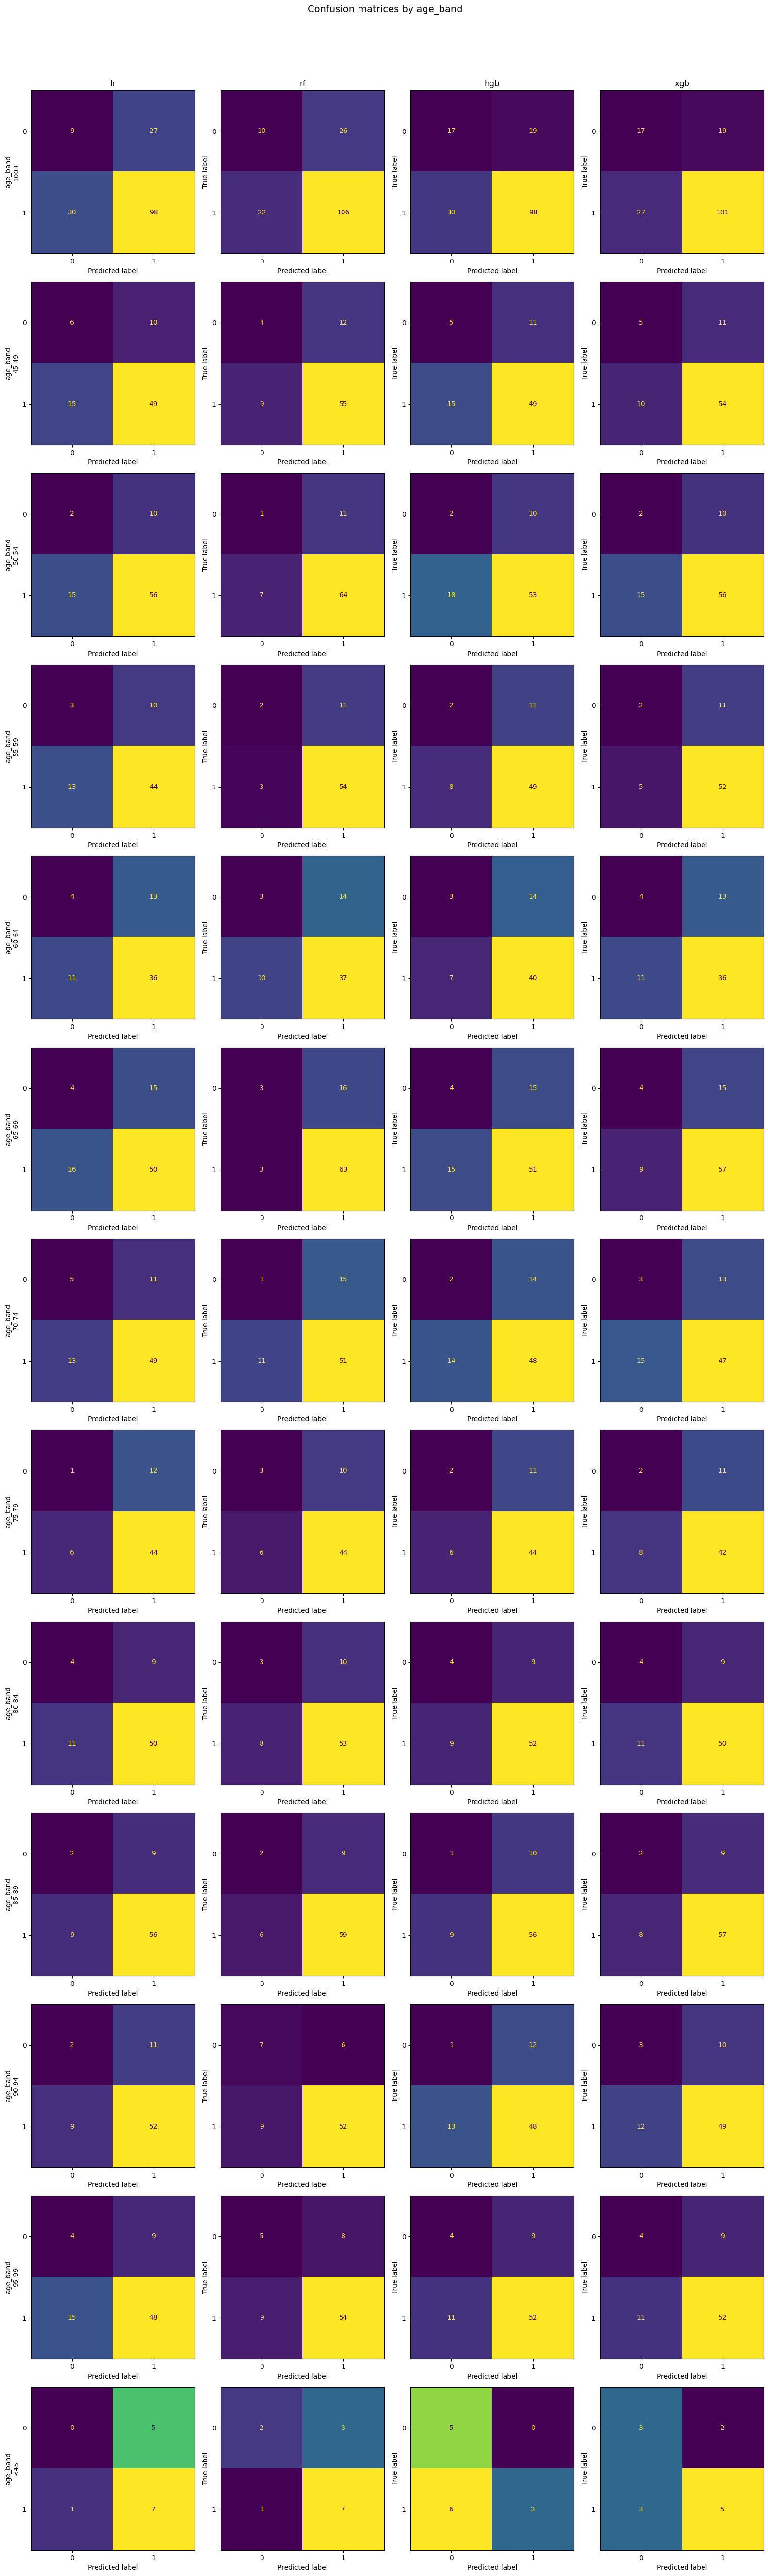

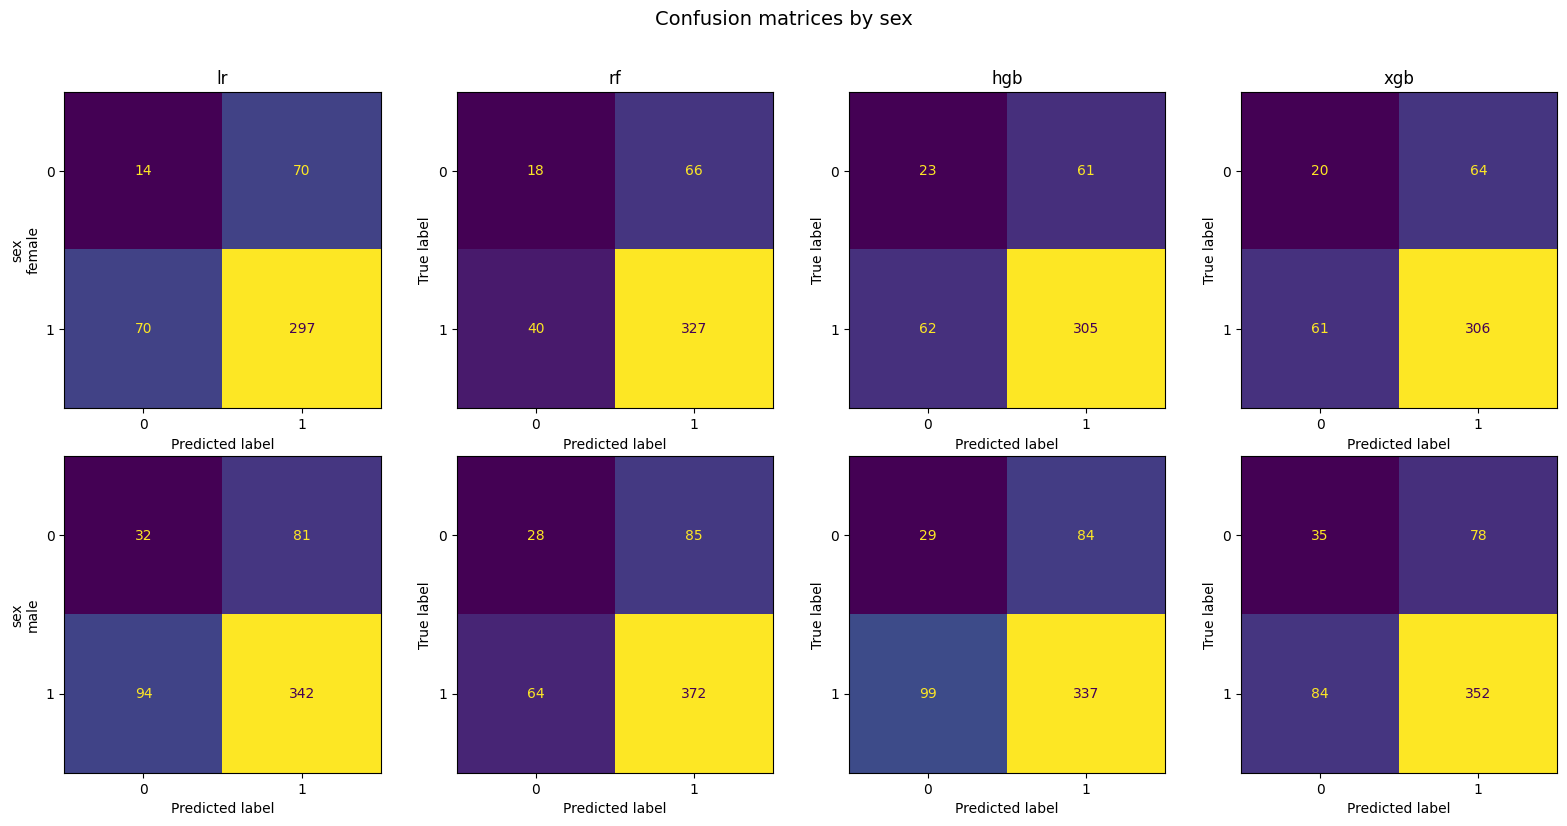

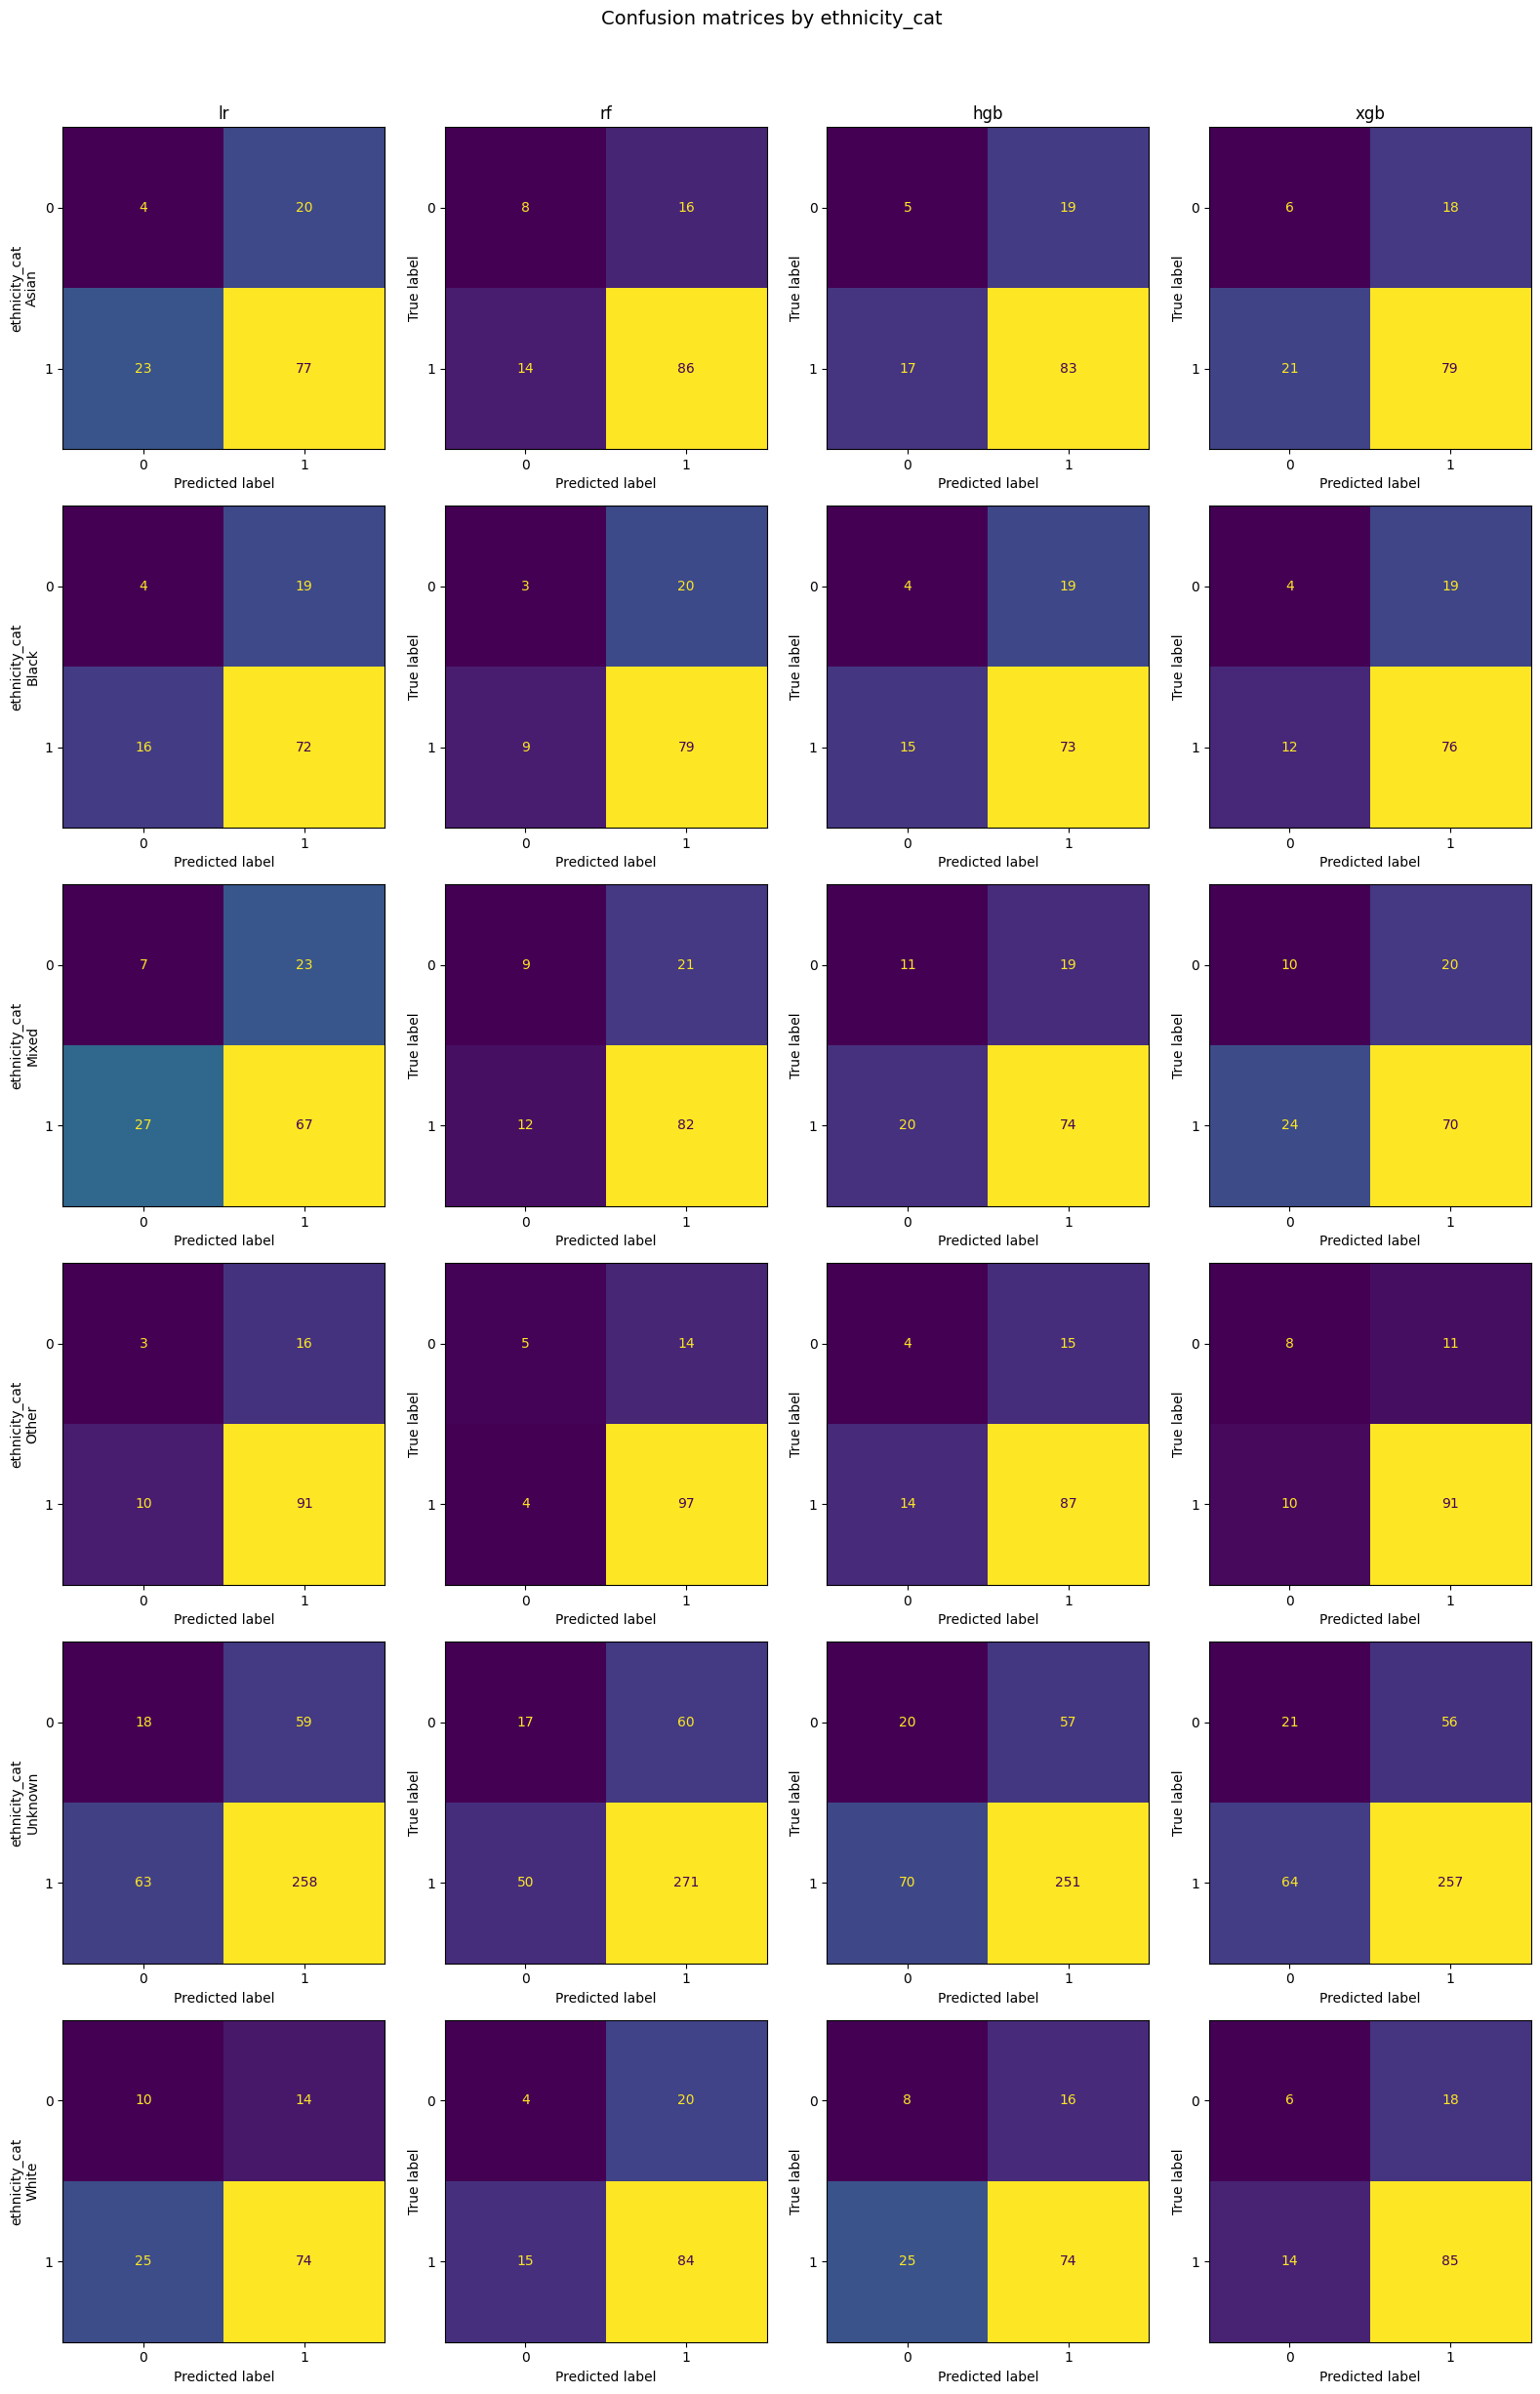

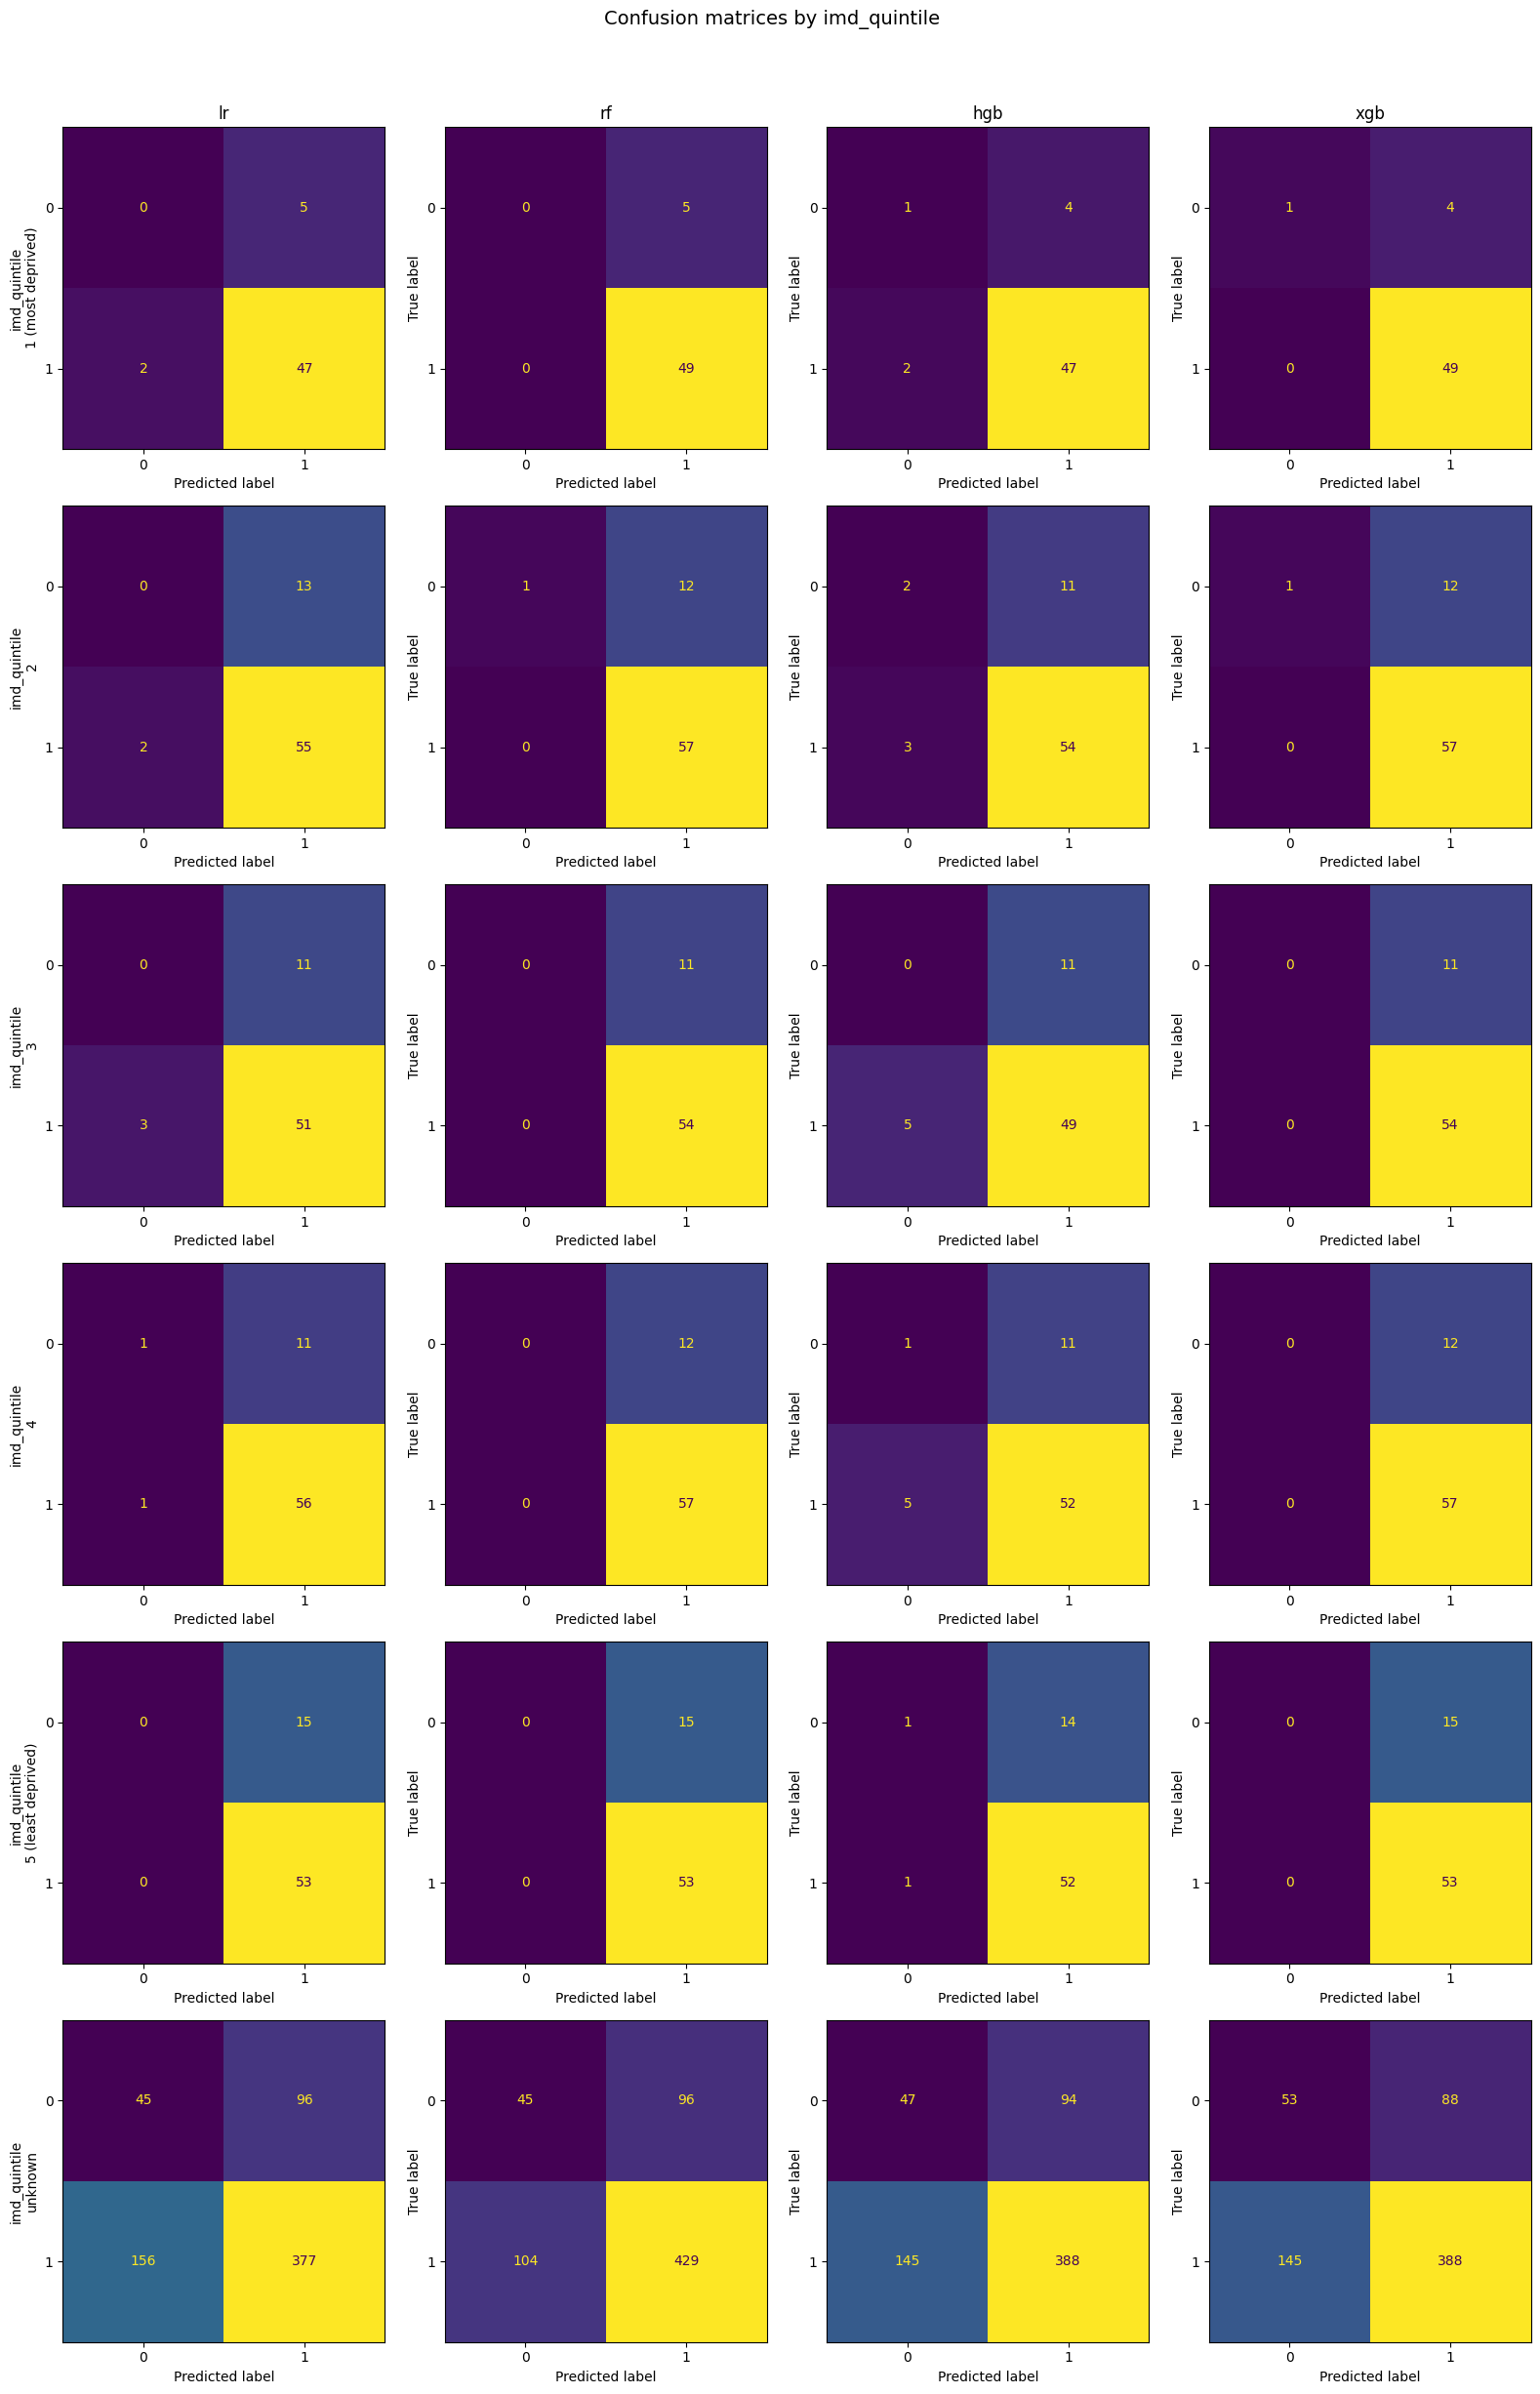

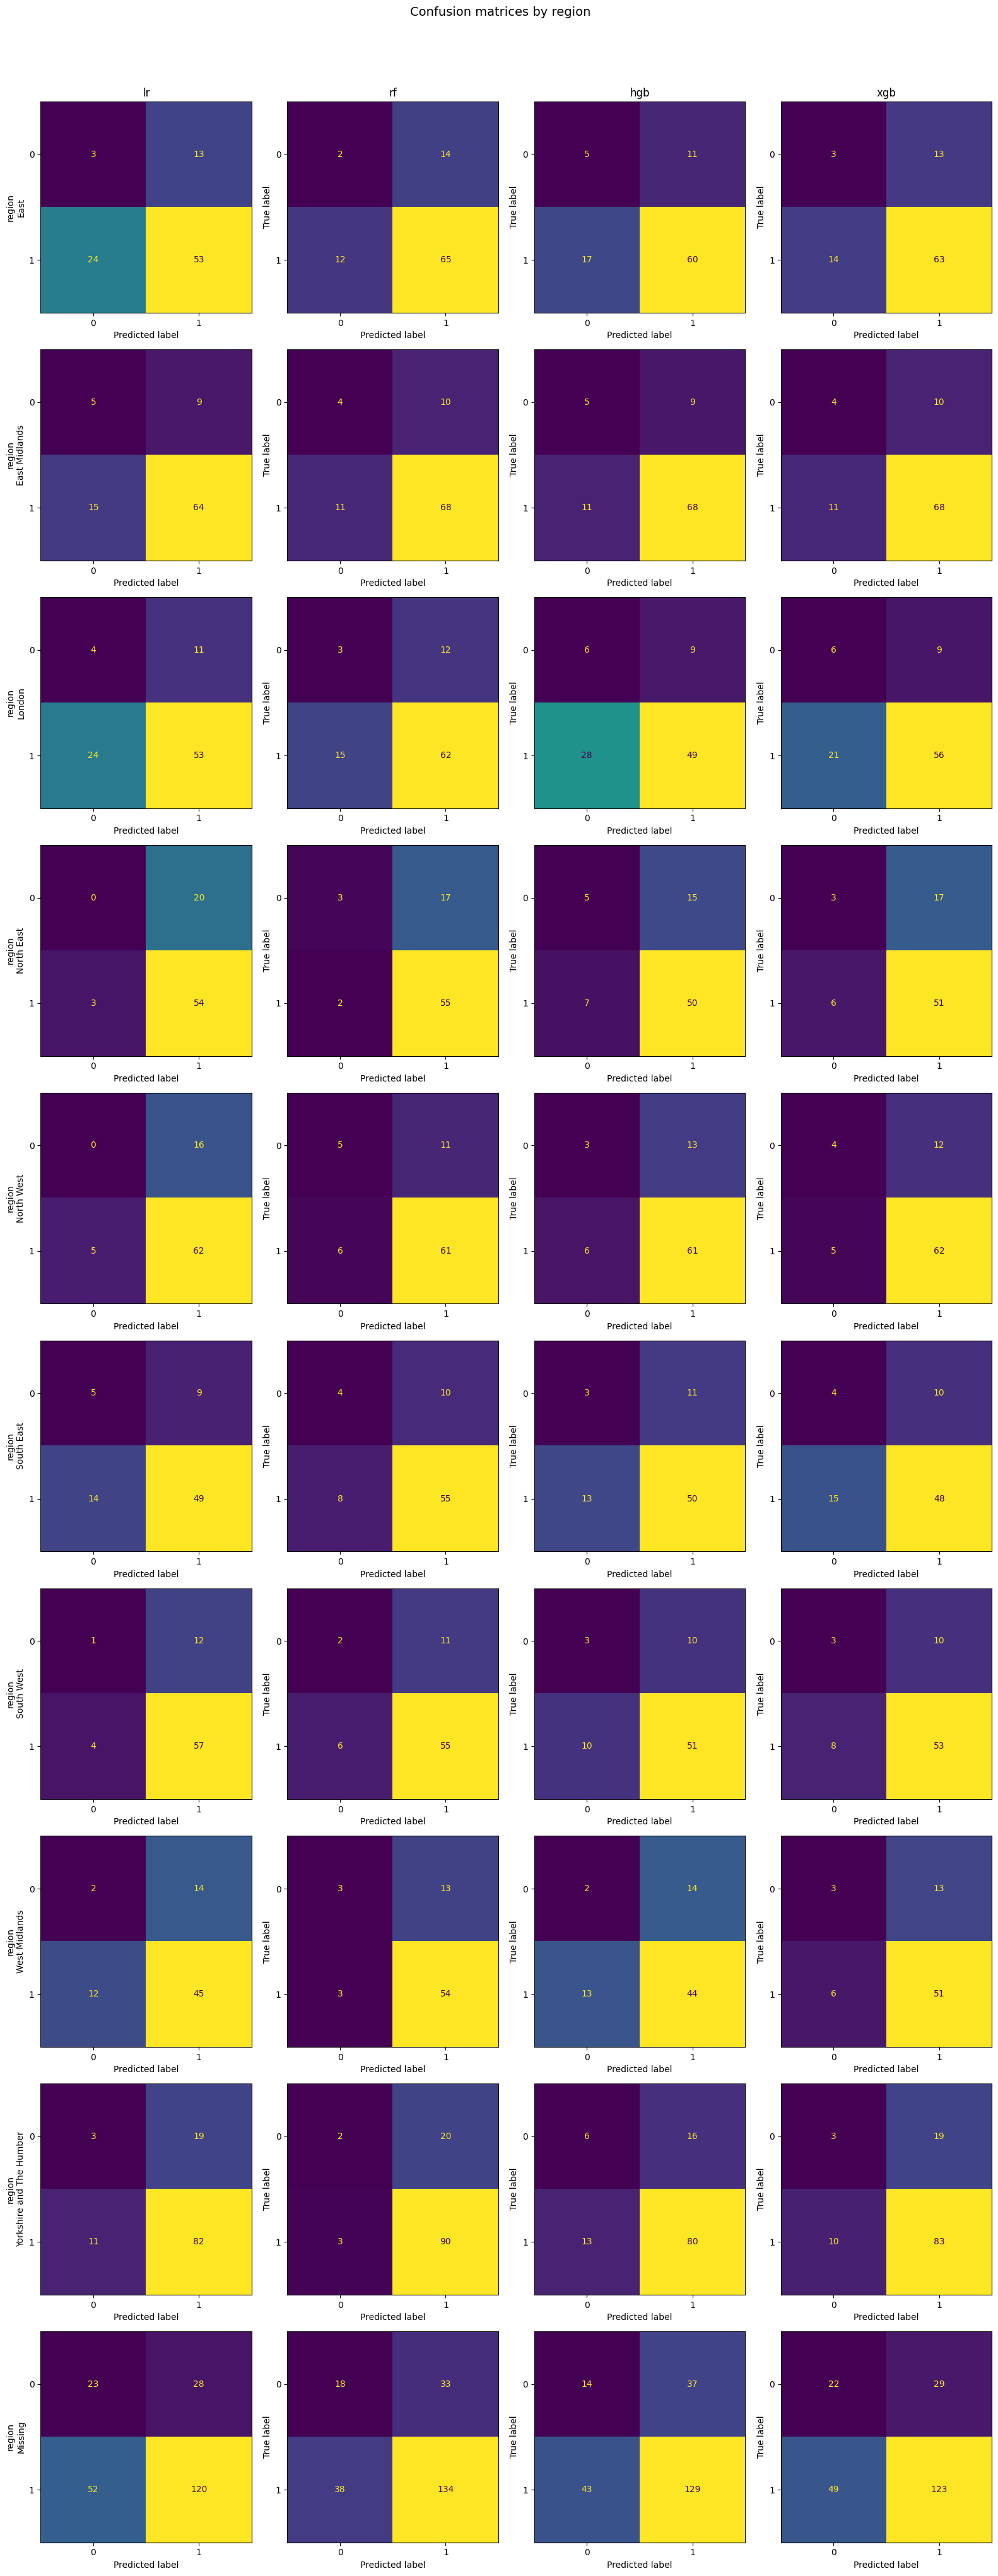

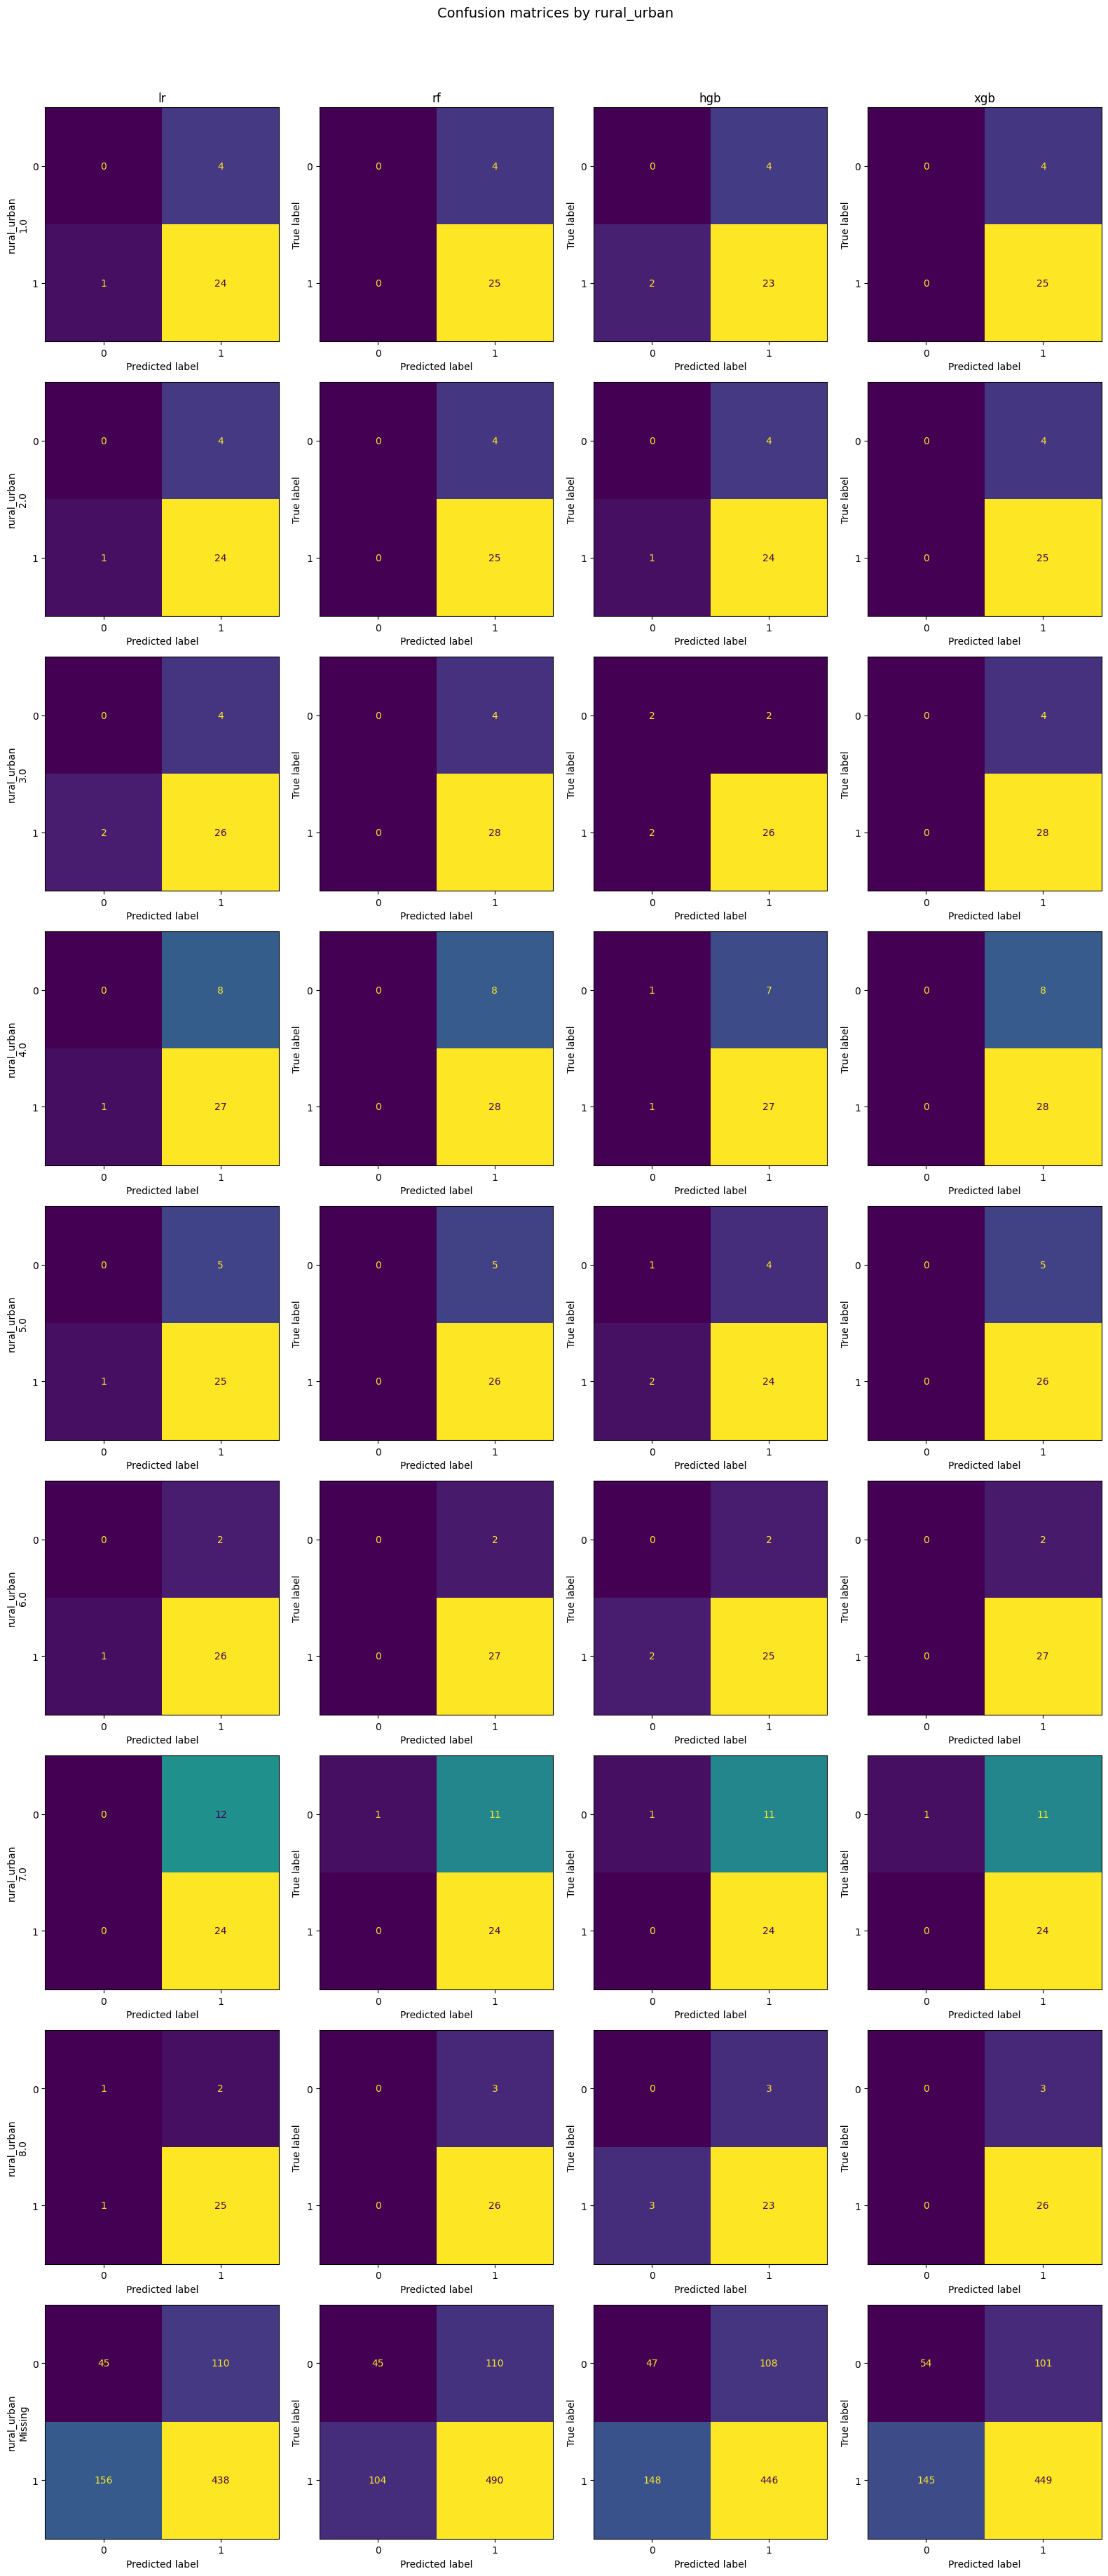

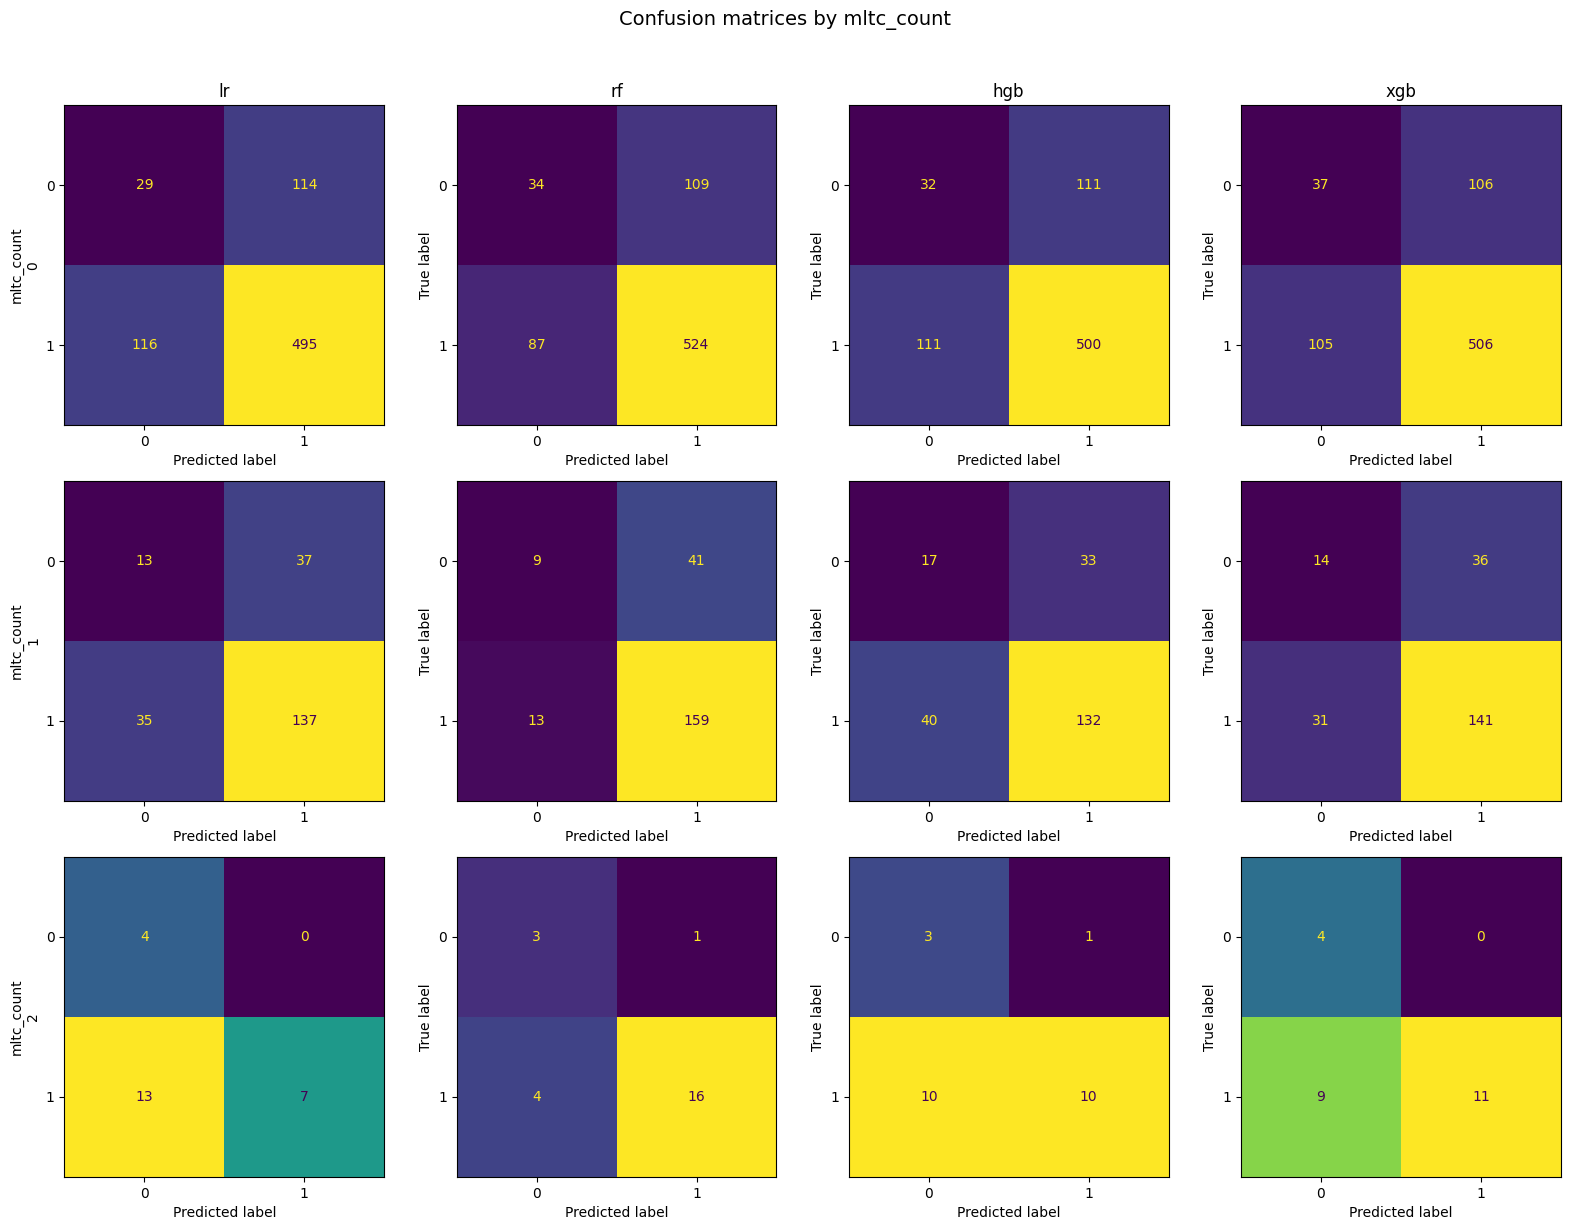

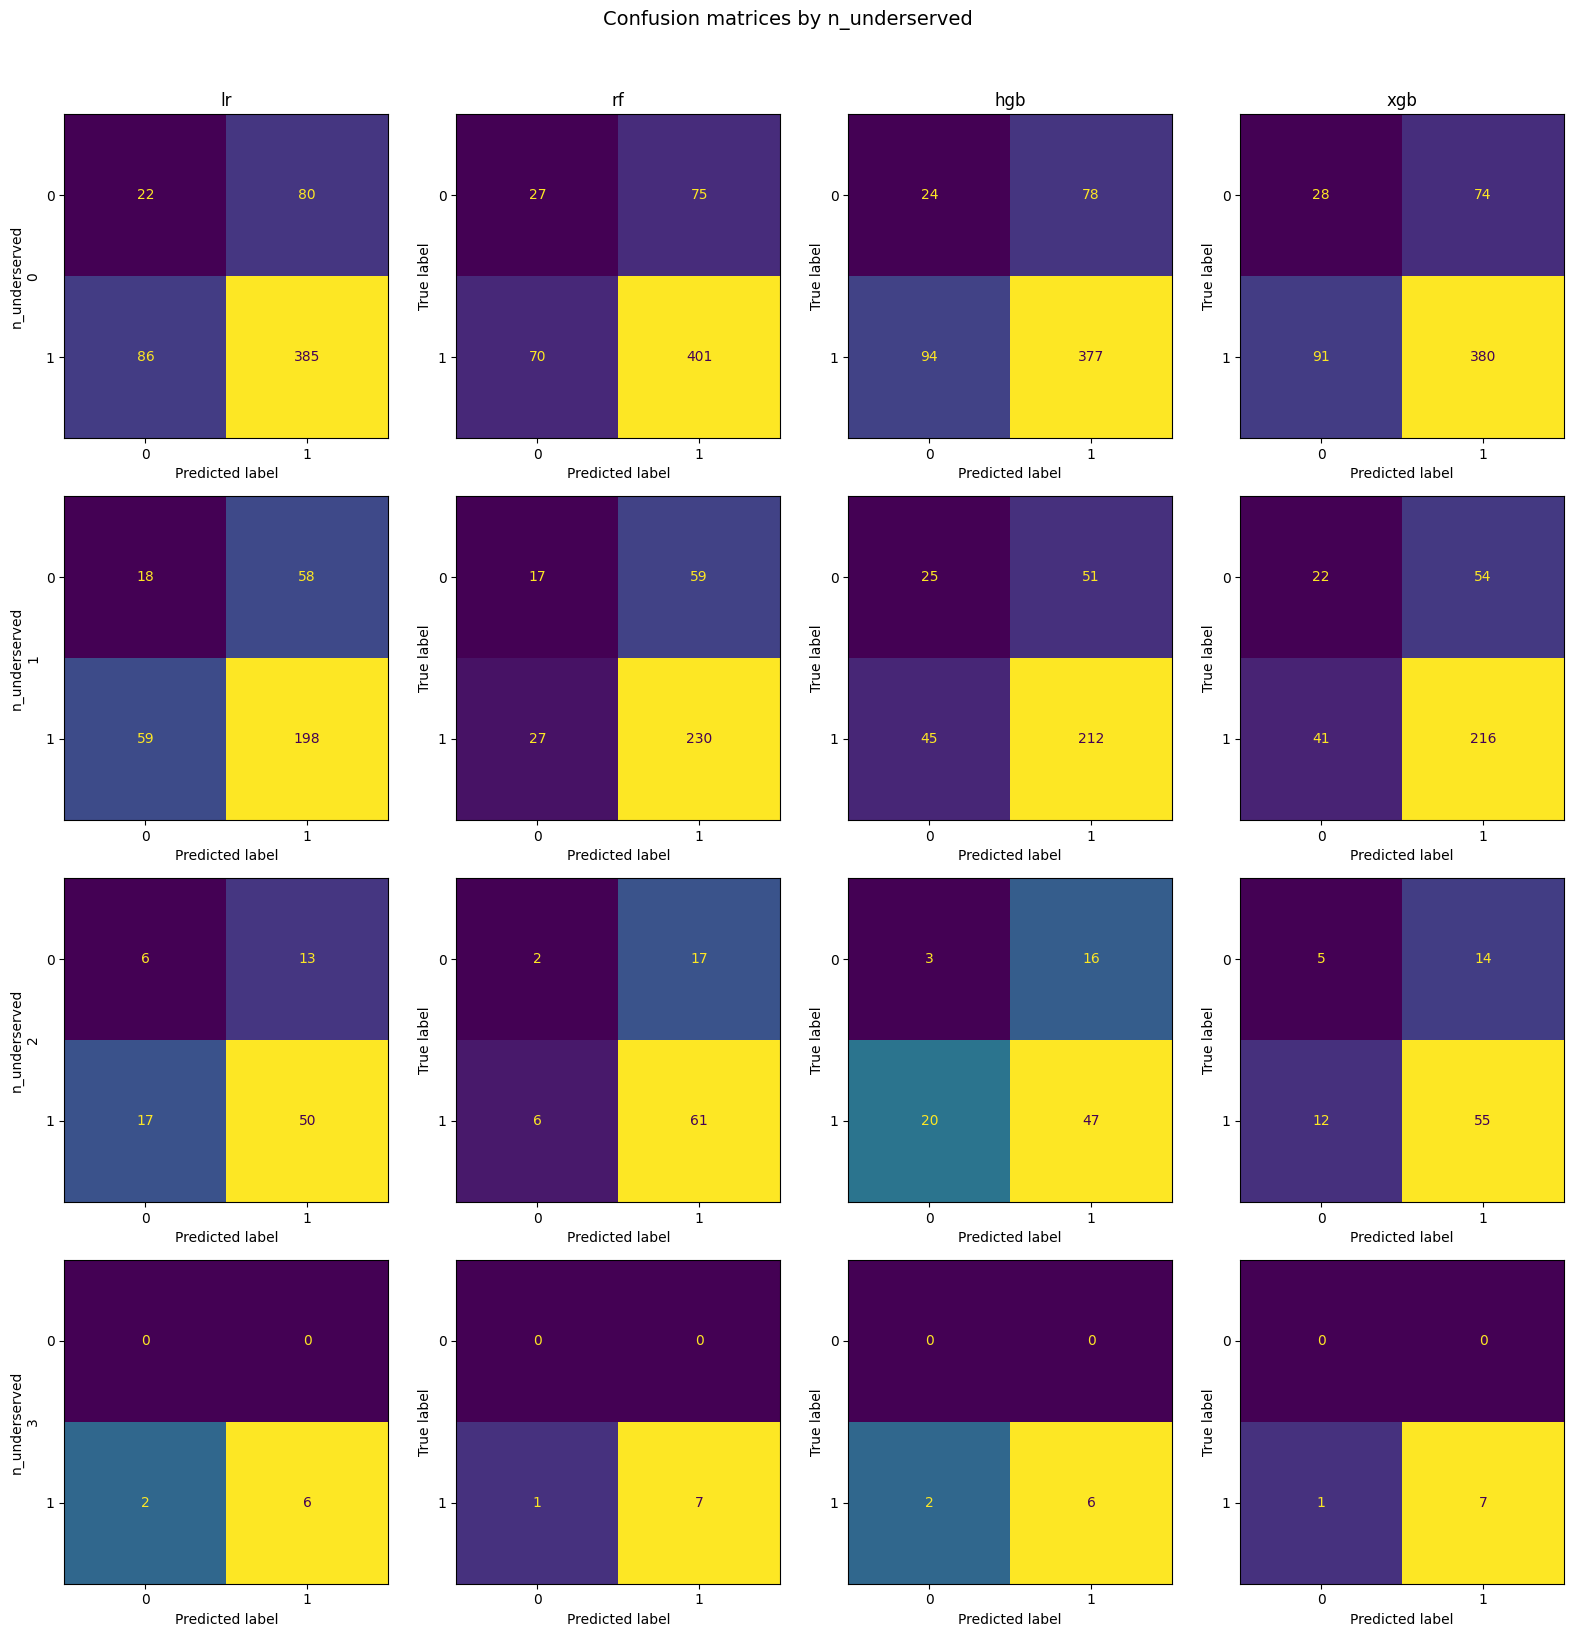

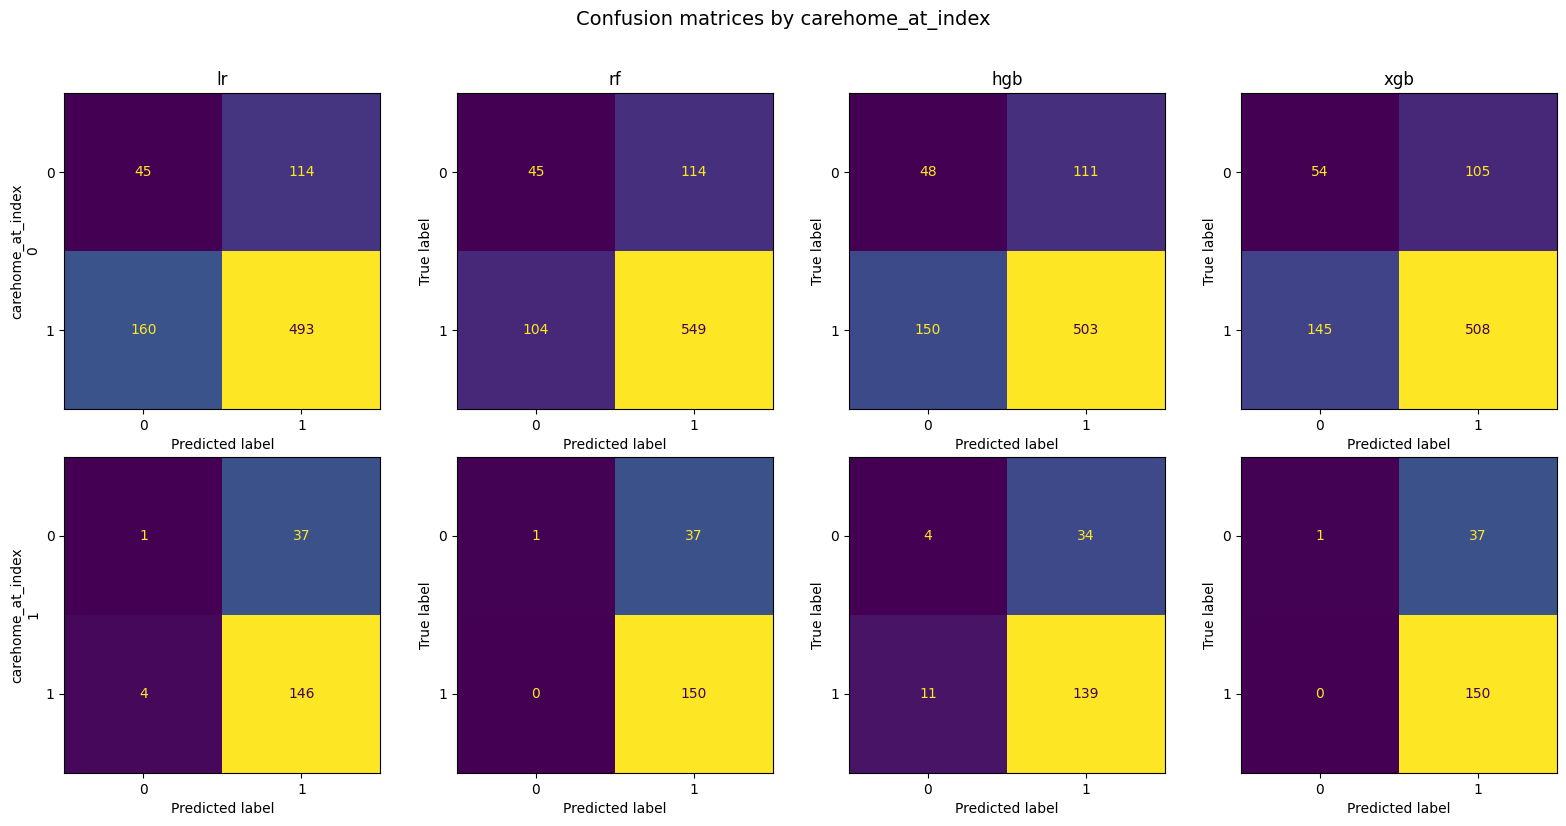

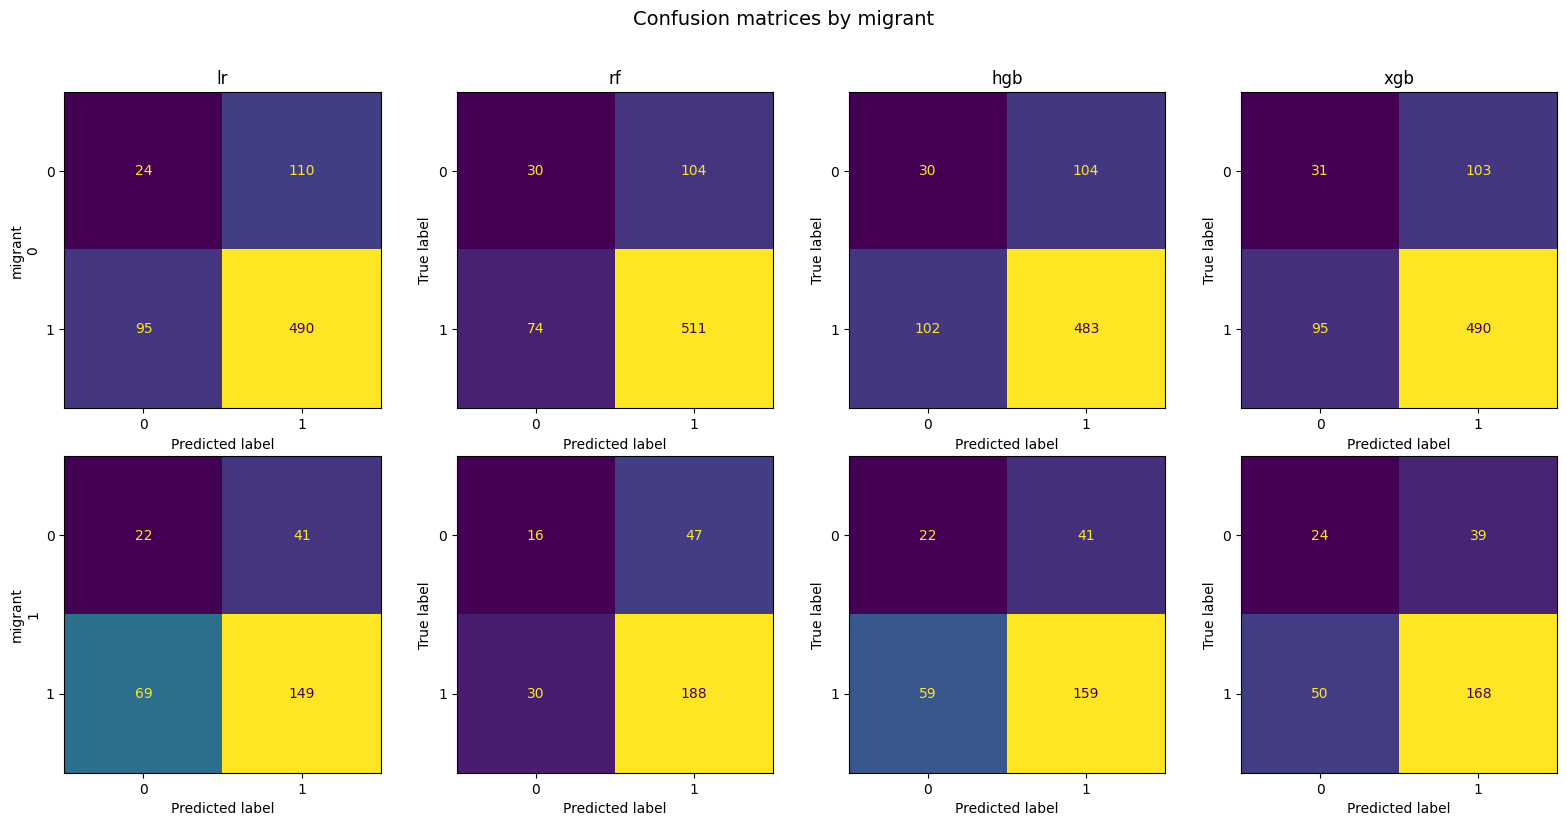

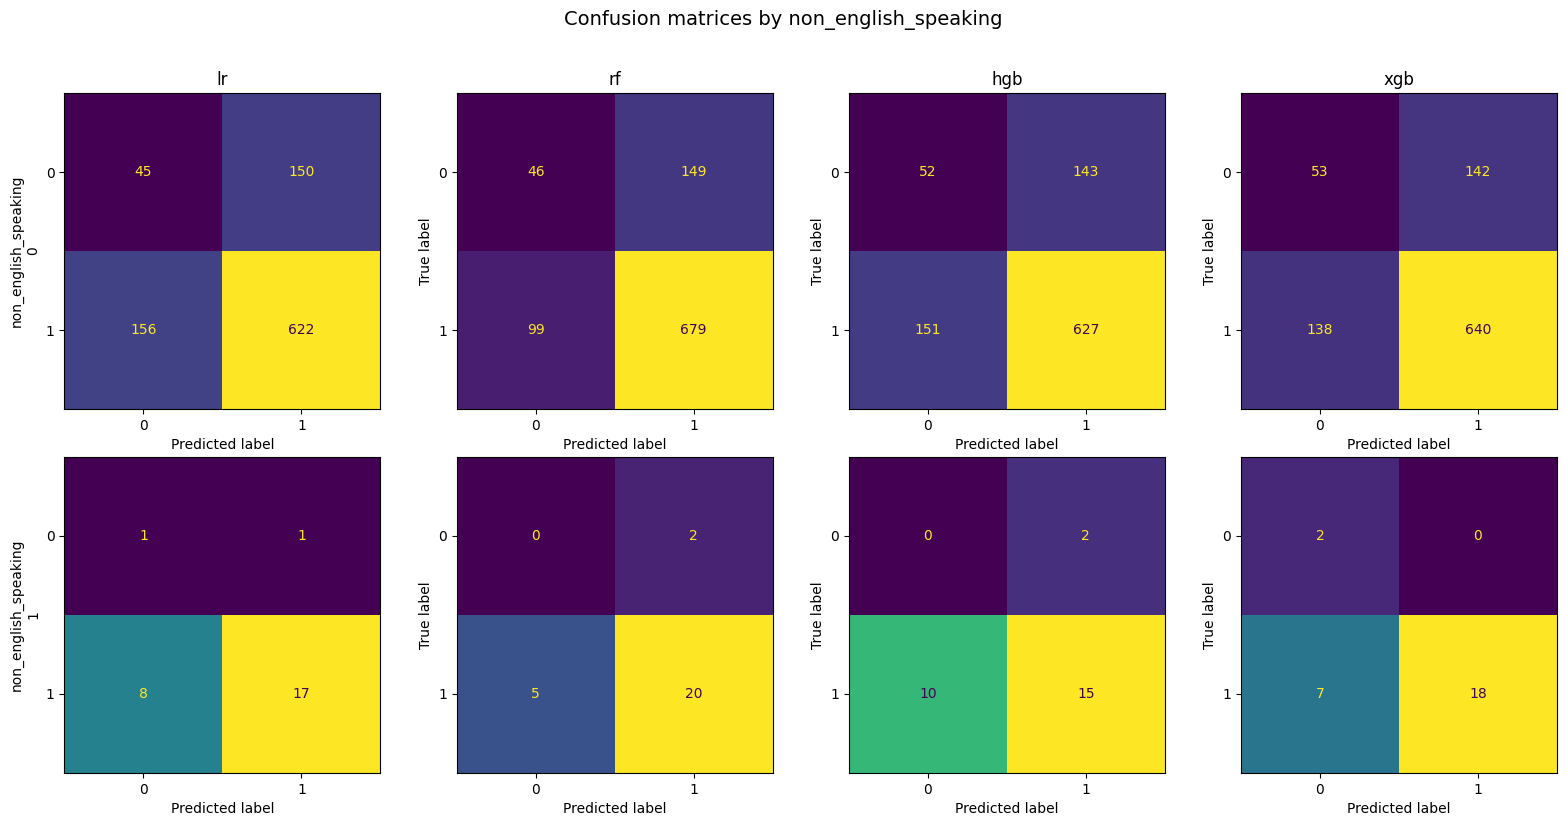

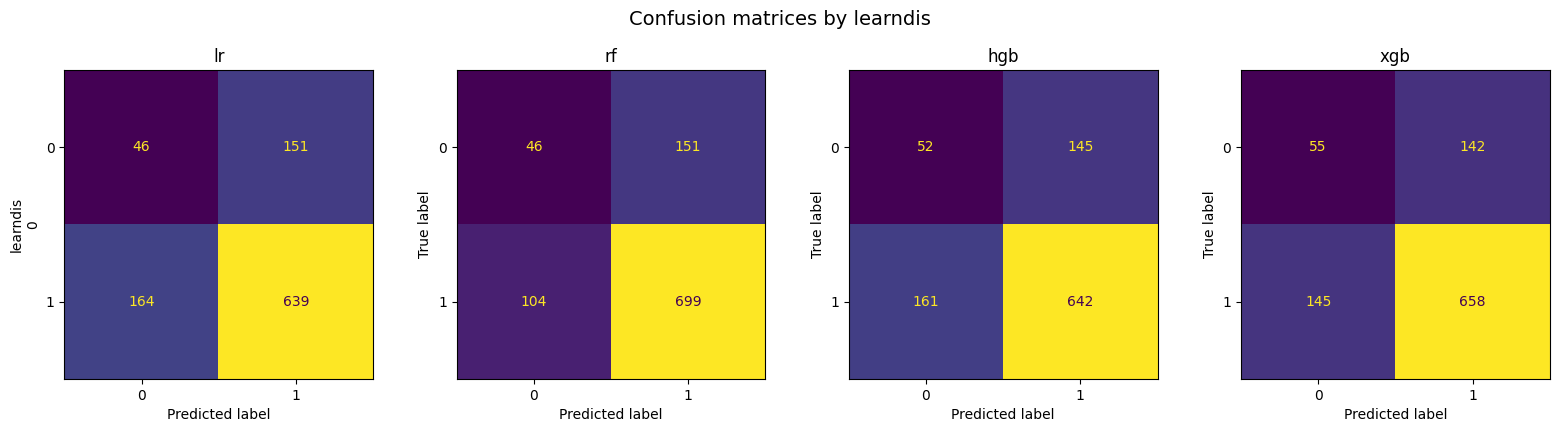

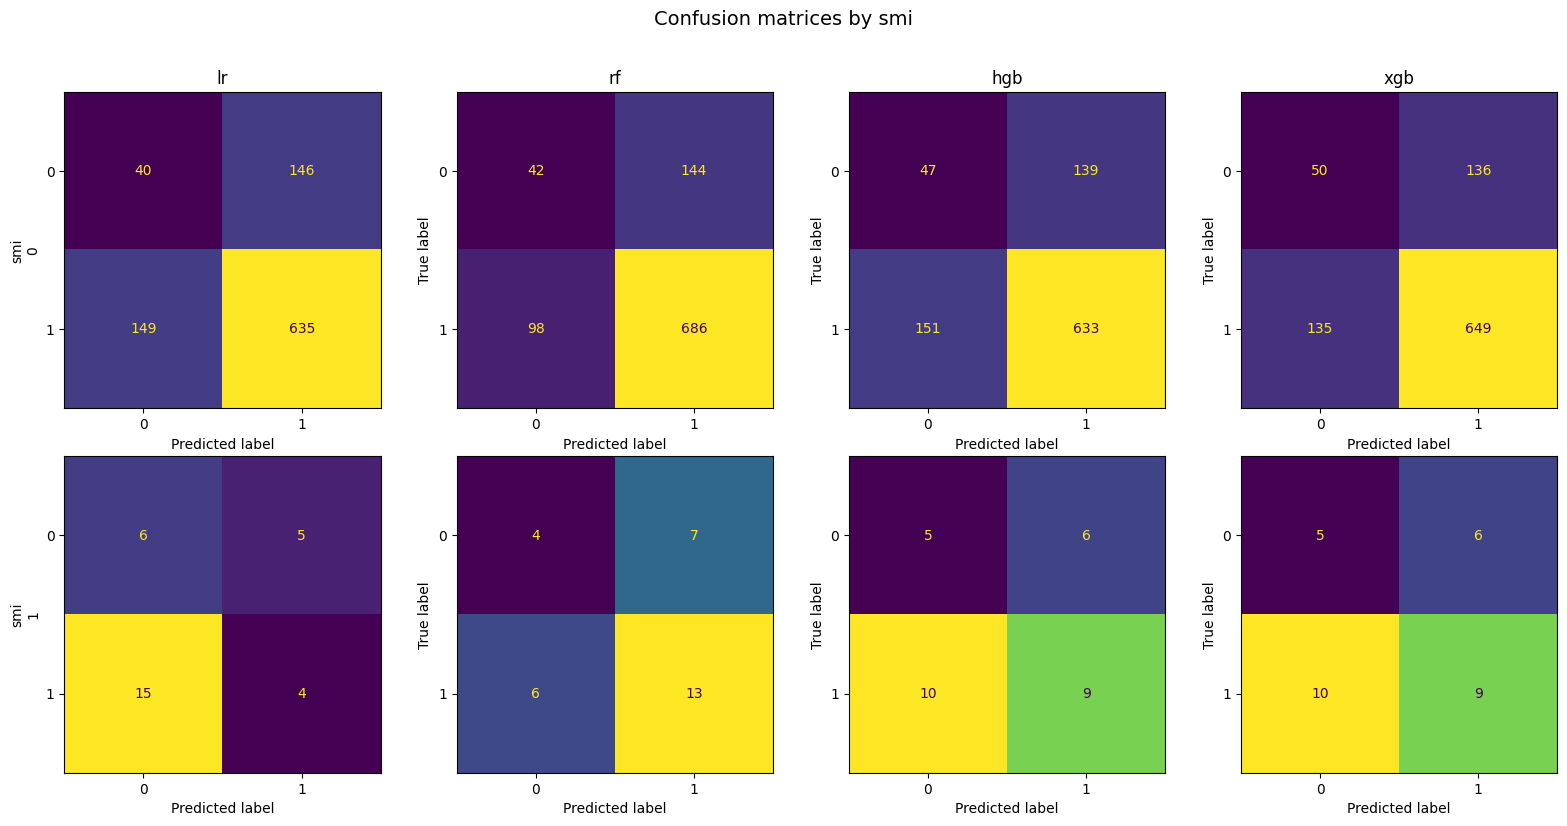

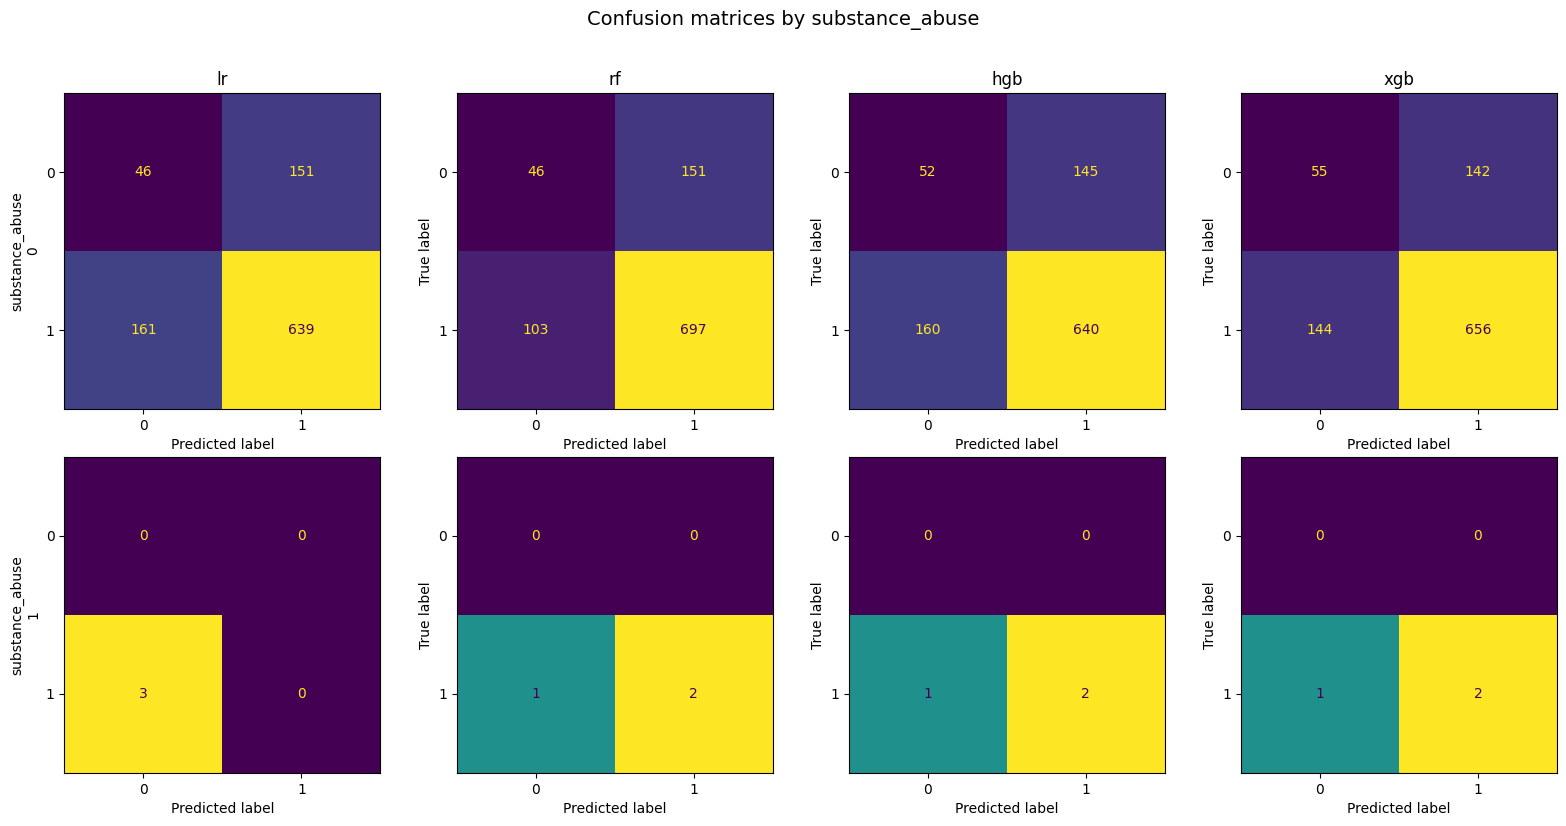

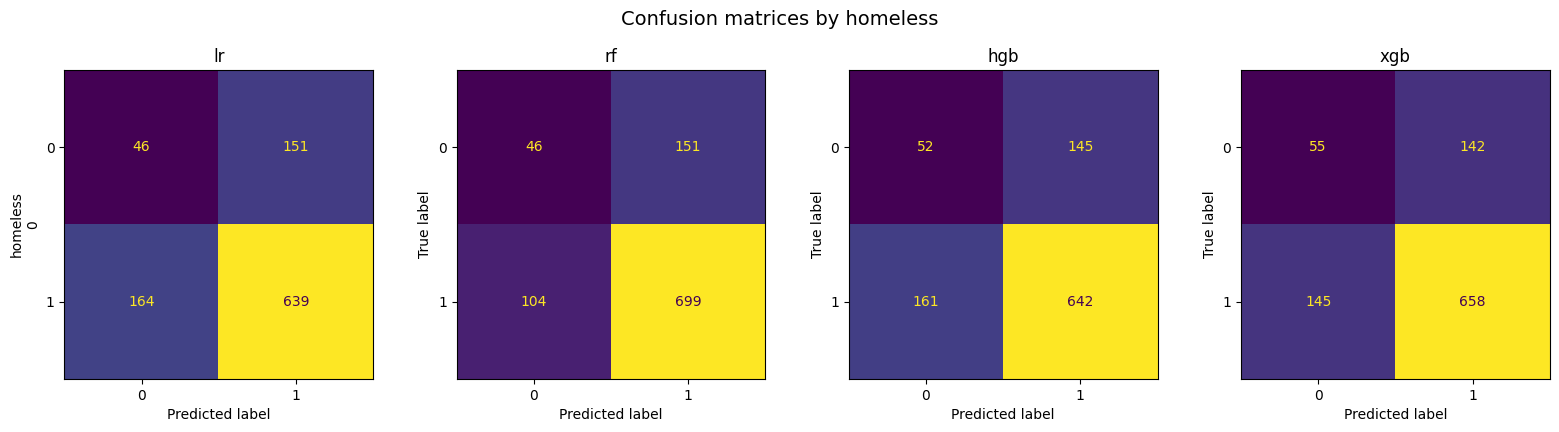

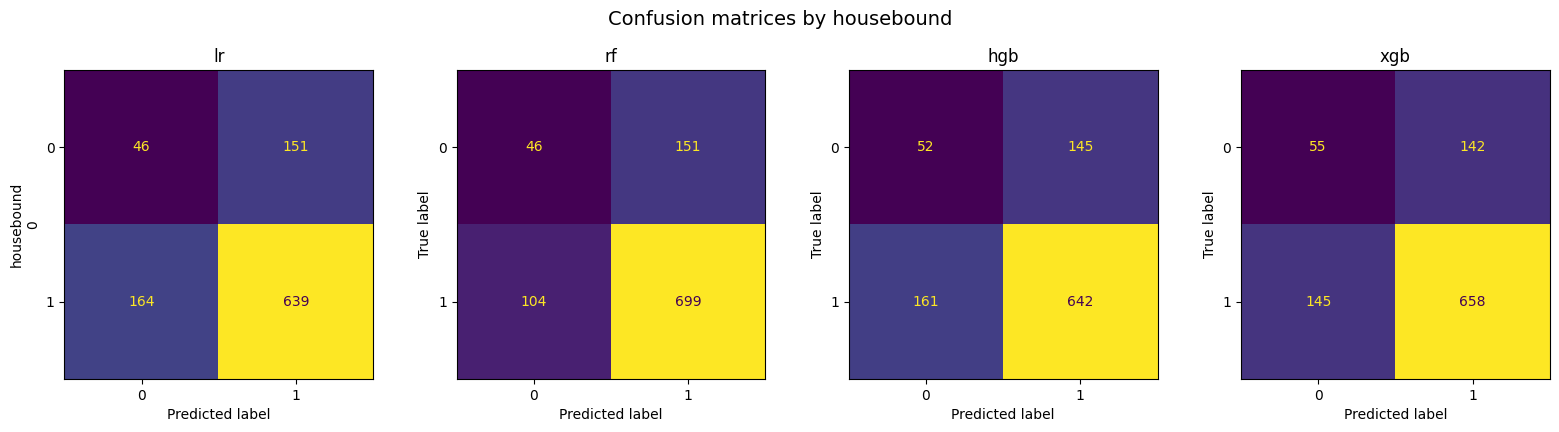

In [62]:
#Only plot CM for dummy data. For real data export csv and plot locally. 
if IS_DUMMY_DATA:

    for subgroup_var in subgroup_vars:

        plot_data = subgroup_confusion_df[
            subgroup_confusion_df["subgroup_variable"] == subgroup_var
        ].copy()

        levels = list(plot_data["subgroup_level"].drop_duplicates())
        n_rows = len(levels)
        n_cols = len(model_names)

        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(4 * n_cols, 4 * n_rows)
        )

        if n_rows == 1 and n_cols == 1:
            axes = np.array([[axes]])
        elif n_rows == 1:
            axes = np.array([axes])
        elif n_cols == 1:
            axes = np.array([[ax] for ax in axes])

        for i, level in enumerate(levels):

            if pd.isna(level):
                level_data = plot_data[
                    plot_data["subgroup_level"].isna()
                ].copy()
                level_label = "Missing"
            else:
                level_data = plot_data[
                    plot_data["subgroup_level"] == level
                ].copy()
                level_label = level

            for j, model_name in enumerate(model_names):

                ax = axes[i, j]

                row = level_data[
                    level_data["model"] == model_name
                ]

                if row.empty:
                    ax.axis("off")
                    continue

                row = row.iloc[0]

                cm = np.array([
                    [row["tn"], row["fp"]],
                    [row["fn"], row["tp"]],
                ])

                disp = ConfusionMatrixDisplay(
                    confusion_matrix=cm,
                    display_labels=["0", "1"]
                )

                disp.plot(
                    ax=ax,
                    colorbar=False
                )

                if i == 0:
                    ax.set_title(model_name)

                if j == 0:
                    ax.set_ylabel(f"{subgroup_var}\n{level_label}")

        fig.suptitle(
            f"Confusion matrices by {subgroup_var}",
            fontsize=14,
            y=1.02
        )

        plt.tight_layout()
        plt.show()

## 7. SDC and Save

In [63]:
performance_count_cols = [
    "n",
    "n_events",
    "n_nonevents",
    "true_positives",
    "false_positives",
    "true_negatives",
    "false_negatives",
]

confusion_count_cols = [
    "n",
    "tn",
    "fp",
    "fn",
    "tp",
]

if IS_DUMMY_DATA:
    subgroup_performance_output_df = subgroup_performance_df.copy()
    subgroup_confusion_output_df = subgroup_confusion_df.copy()
else:
    subgroup_performance_output_df = subgroup_performance_df.copy()
    subgroup_confusion_output_df = subgroup_confusion_df.copy()

    subgroup_performance_output_df[performance_count_cols] = (
        subgroup_performance_output_df[performance_count_cols]
        .apply(
            apply_disclosure_control,
            threshold=DISCLOSURE_THRESHOLD
        )
    )

    subgroup_confusion_output_df[confusion_count_cols] = (
        subgroup_confusion_output_df[confusion_count_cols]
        .apply(
            apply_disclosure_control,
            threshold=DISCLOSURE_THRESHOLD
        )
    )

    subgroup_performance_output_df["event_rate"] = (
        subgroup_performance_output_df["n_events"]
        / subgroup_performance_output_df["n"]
    )

subgroup_performance_output_df.to_csv(
    os.path.join(OUTPUT_DIR, "subgroup_test_performance.csv"),
    index=False,
)

subgroup_confusion_output_df.to_csv(
    os.path.join(OUTPUT_DIR, "subgroup_confusion_matrices.csv"),
    index=False,
)

print("Saved subgroup performance and confusion matrices")

Saved subgroup performance and confusion matrices
